In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation



Working directory: /mnt/home/focus


/opt/conda/lib/python3.11/site-packages/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/conda/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)
/opt/conda/lib/python3.11/site-packages/warp_maniskill/warp/codegen.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp
/opt/conda/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: DeprecationWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", D

In [2]:
# Import agent model (WM + Actor Critic)
agent_path = Path(f'/mnt/public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrained_models/skill_focus/dmc/reacher_hard/1/snapshot_1000000.pt')

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
        agent.device = device
        agent.wm.device = device
        agent.wm.rssm.device = device
        agent.wm.rssm._cell.device = device
    return agent, step

agent, global_step = load_agent(agent_path)

In [3]:
from hydra import compose, initialize
from omegaconf import OmegaConf

initialize(config_path="../../../../public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrain/41a31fc2cd0e0ccf75b1449541cc2694/code/exp_local/2024.01.02/143841_skill_focus_reacher_hard_/.hydra", job_name="config")
cfg = compose(config_name="config")

/tmp/ipykernel_11701/725984538.py:4: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../../../../public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrain/41a31fc2cd0e0ccf75b1449541cc2694/code/exp_local/2024.01.02/143841_skill_focus_reacher_hard_/.hydra", job_name="config")


In [4]:
obs_type = "pixels"
action_repeat = 2
snapshot_ts = global_step * action_repeat
seed = 0

domain = "dmc"  
task = "reacher_hard"

# Env creation
env = make(cfg.domain, cfg.task, obs_type, frame_stack=1, 
                    action_repeat=action_repeat, seed=seed, env_config=cfg.env)

env.reset()

/opt/conda/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased
Hyperparameters read from the model weights: C^k=64, C^v=512, C^h=64
Single object mode: False


/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, device=self.device)


{'reward': 0.0,
 'is_first': True,
 'is_last': False,
 'is_terminal': False,
 'rgb': array([[[ 37,  37,  38, ...,  38,  38,  37],
         [ 38,  39,  39, ...,  73,  73,  38],
         [ 38,  39,  39, ...,  74,  73,  38],
         ...,
         [ 38,  73,  73, ...,  39,  39,  38],
         [ 37,  72,  73, ...,  39,  39,  37],
         [ 37,  37,  38, ...,  38,  37,  37]],
 
        [[ 62,  62,  62, ...,  62,  62,  62],
         [ 62,  78,  78, ..., 110, 110,  62],
         [ 62,  78,  78, ..., 112, 110,  62],
         ...,
         [ 62, 110, 111, ...,  78,  78,  62],
         [ 62, 110, 110, ...,  78,  78,  62],
         [ 62,  62,  62, ...,  62,  62,  62]],
 
        [[ 86,  86,  87, ...,  87,  86,  86],
         [ 86, 115, 115, ..., 149, 149,  86],
         [ 87, 115, 115, ..., 150, 149,  87],
         ...,
         [ 87, 149, 150, ..., 115, 115,  87],
         [ 86, 148, 149, ..., 115, 115,  86],
         [ 86,  86,  87, ...,  87,  86,  86]]], dtype=uint8),
 'proprio': array([     

/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, device=self.device)


-3.14
-2.8094736842105266
-2.4789473684210526
-2.148421052631579
-1.8178947368421052
-1.4873684210526315
-1.156842105263158
-0.8263157894736839
-0.49578947368421034
-0.16526315789473678
0.16526315789473722
0.4957894736842108
0.8263157894736843
1.156842105263158
1.4873684210526323
1.817894736842106
2.1484210526315795
2.478947368421053
2.8094736842105266
3.14


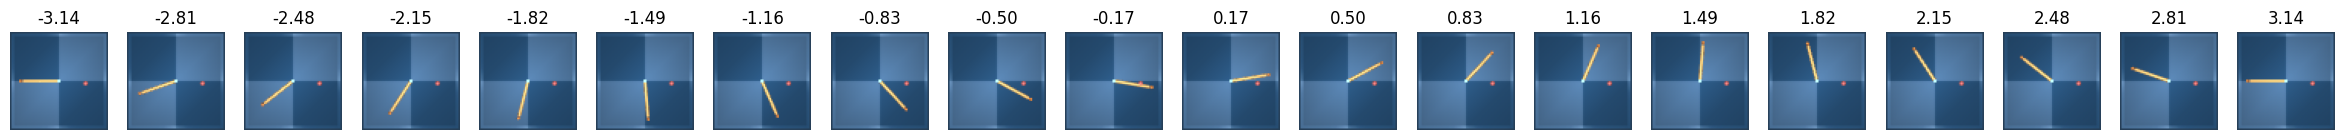

In [27]:
import matplotlib.pyplot as plt

env.reset()
# 1 - sample position uniformelly distributed along one axis of the workspace
x_pos = np.linspace(-3.14, 3.14, num=20)

# 2 - Get observations from the environment with the sampled position
pos_dict = {}
for pos in x_pos:
    print(pos)
    env.set_goal_state([pos, 0])
    pos_dict[pos] = env.step([0,0])
    

# 2.a - debug: plot the rgb observations
fig, ax = plt.subplots(1, len(pos_dict), figsize=(30, 10))
for i in range(len(pos_dict)):
    ax[i].imshow(pos_dict[x_pos[i]]["rgb"].transpose(1,2,0))
    ax[i].set_title(f"{x_pos[i]:.2f}")
    ax[i].axis('off')    
    

In [28]:
# 3- Feed observations to the encoder and get object features, collect features in a list
feat = []
for pos, obs in pos_dict.items():
    # obs = torch.from_numpy(obs["rgb"].copy()).unsqueeze(0).float().to(agent.device)
    obs = {
            k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
            for k, v in obs.items()
        }
    
    with torch.no_grad():
        feat.append(agent.wm.encoder(agent.wm.preprocess(obs)).cpu().numpy()[0])
        # pos_dict[pos]["features"] = features.cpu().numpy()
    
feat = np.array(feat)
feat.shape

(20, 1936)

In [29]:
# 4 - t-SNE plot the features
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=3).fit_transform(feat)


[[0, -0.24, -0.0], [0, -0.227, -0.078], [0, -0.189, -0.148], [0, -0.131, -0.201], [0, -0.059, -0.233], [0, 0.02, -0.239], [0, 0.097, -0.22], [0, 0.163, -0.177], [0, 0.211, -0.114], [0, 0.237, -0.039], [0, 0.237, 0.039], [0, 0.211, 0.114], [0, 0.163, 0.177], [0, 0.097, 0.22], [0, 0.02, 0.239], [0, -0.059, 0.233], [0, -0.131, 0.201], [0, -0.189, 0.148], [0, -0.227, 0.078], [0, -0.24, 0.0]]


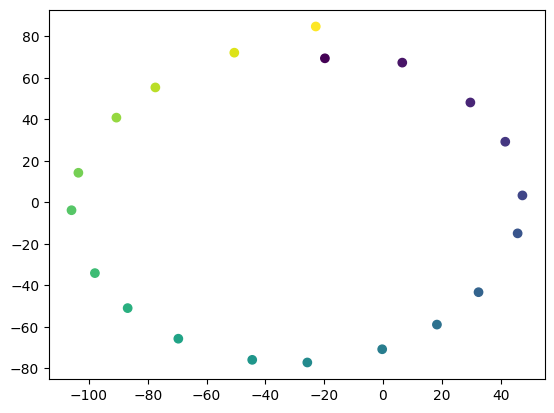

In [30]:
# 5 - associate each feature with a color that depens on the position along one axis

pos_list = np.fromiter(pos_dict.keys(), dtype=float)

# color_list = []
# for items in pos_dict.values():
    # color_list.append([0, *list((items["objects_pos"][0]))])
    
print(color_list)
# print(color_list.shape)
plt.scatter(X_embedded[:,0], X_embedded[:,1], c=pos_list)


In [18]:
# Code for separate colors along axis
# x_axis = np.linspace(-5, 5, num=20)
# y_axis = np.linspace(-5, 5, num=20)
# axis_color = np.linspace(0, 1, num=20)
# color = []
# for i in range(len(x_axis)):
#     color.append([axis_color[i], 1-axis_color[i], 0])

# plt.scatter(x_axis, y_axis, c=color)